# EGFP design campaign — scaffold vs design vs target peaks

Visualize, for each of the 4 EGFP→target pairs, where the **scaffold** and **target** sit in
`(excitation, emission)` space and where the **guided designs** land, as **predicted by the
surrogate** (ESM-2 `cnn-max-d1`, all-data).

- **scaffold (measured)** and **target (measured)** — the real FPBase `(ex, em)` peaks.
- **design (surrogate)** — the surrogate's predicted `(ex, em)` for each of the 6 designed sequences
  per pair (final iteration), with the per-trial trajectory (rounds 0→3) drawn faintly.

> **No oracle for this task.** The design predictions come from the same surrogate that guided the
> search, so they are *in-sample / optimistic*, not independent validation. The scaffold and target
> markers are measured values; only the design markers are model predictions.

Data source: `guided_design/designs/design_*.csv` (produced by `guided_design/design_campaign.py`).

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_designs(designs_dir):
    fs = sorted(glob.glob(str(Path(designs_dir) / "design_*.csv")))
    d = pd.concat([pd.read_csv(f) for f in fs], ignore_index=True)
    d["pair"] = d["scaffold_name"] + " \u2192 " + d["target_name"]
    return d


def best_per_trial(d):
    """One row per (pair, trial): the ITERATION ROUND (>=1) with the smallest surrogate peak_err.
    Round 0 is the untouched scaffold and is EXCLUDED, so a 'best design' is always an actual edited
    sequence (never the original scaffold), even if every design is worse than the scaffold."""
    dd = d[d["round"] >= 1]
    idx = dd.groupby(["pair", "trial"])["peak_err"].idxmin()
    return dd.loc[idx].reset_index(drop=True)


def pair_summary(d):
    """Per pair: scaffold error (round 0) and mean/best over each trial's BEST round."""
    bt = best_per_trial(d)
    out = []
    for p, g in d.groupby("pair"):
        b = bt.loc[bt["pair"] == p, "peak_err"]
        out.append(dict(pair=p, scaffold_err=g.loc[g["round"] == 0, "peak_err"].iloc[0],
                        mean_design=b.mean(), best_design=b.min()))
    return pd.DataFrame(out).sort_values("best_design").reset_index(drop=True)


# locate guided_design/designs whether the notebook runs from the campaign root or the repo root
_cands = [Path("guided-design/designs"), Path("guided_design/designs"),
          Path("design-campaign-EGFP/guided-design/designs"),
          Path("design-campaign-EGFP/guided_design/designs"),
          Path.cwd() / "guided-design" / "designs", Path.cwd() / "guided_design" / "designs"]
DESIGNS = next((c for c in _cands if c.exists()), None)
assert DESIGNS is not None, "could not find guided_design/designs; run this notebook from design-campaign-EGFP/"
FIGDIR = DESIGNS.parent.parent / "figures"; FIGDIR.mkdir(exist_ok=True)

df = load_designs(DESIGNS)
RMAX = int(df["round"].max())
pairs = df.groupby("pair")["scaffold_idx"].first().index.tolist()
summary = pair_summary(df)

# The two GIBBS strategies are target-free (one design_<scaffold>.csv): selection never sees a
# target, so a run is a single design effort per scaffold. Reconstruct a per-target view by pairing
# each design with every target's peaks (taken from df) and recomputing the surrogate distance, so
# the comparison cells below get frames aligned 1:1 with df's targets.
#   gibbs-sampling/  draws from the ESM-2 masked-LM conditional
#   msa-gibbs/       draws from the SAME 763-sequence family profile msa-guided/ uses, i.e. it is
#                    the unguided control that isolates the proposal from the surrogate steering.
# Note peak_err here is POST-HOC for both: nothing in either run optimized it.
_TG = df[["target_name", "target_idx", "target_ex", "target_em"]].drop_duplicates()

def _find(rel):
    """Locate a campaign subfolder whether the notebook runs from the campaign dir or the repo."""
    for base in (Path("."), Path("design-campaign-EGFP"), Path.cwd()):
        if (base / rel).exists():
            return base / rel
    raise AssertionError(f"could not find {rel}")

def load_target_free(designs_dir):
    """Expand a target-free run into df's per-target frame; returns (raw, per-target)."""
    b = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(str(designs_dir / "design_*.csv")))],
                  ignore_index=True)
    d = b.merge(_TG, how="cross")
    d["pair"] = d["scaffold_name"] + " \u2192 " + d["target_name"]
    d["peak_err"] = 0.5 * ((d["pred_ex"] - d["target_ex"]).abs()
                           + (d["pred_em"] - d["target_em"]).abs())
    return b, d

GIBBS = _find("gibbs-sampling/designs")
MGIBBS = _find("msa-gibbs/designs")
_gbase, dfg = load_target_free(GIBBS)
_mgbase, dfmg = load_target_free(MGIBBS)
RMAX_G = int(dfg["round"].max())
summary_g = pair_summary(dfg)

print(f"loaded {df['pair'].nunique()} pairs, {len(df)} rows | rounds 0..{RMAX} | trials {df.trial.nunique()}")
for _n, _b in [("gibbs (ESM-2)", _gbase), ("gibbs (MSA)", _mgbase)]:
    print(f"{_n:14} target-free: {_b['designed_seq'].nunique()} unique designs \u00d7 "
          f"{dfg['target_name'].nunique()} targets | {_b.trial.nunique()} trials | "
          f"rounds 0..{int(_b['round'].max())}")
print(f"[each trial's best round] improved best over scaffold: "
      f"{(summary.best_design < summary.scaffold_err).sum()}/{len(summary)} | "
      f"best within 10 nm: {(summary.best_design < 10).sum()}/{len(summary)}")
summary.round(1)

loaded 2 pairs, 576 rows | rounds 0..3 | trials 96
gibbs (ESM-2)  target-free: 289 unique designs × 2 targets | 96 trials | rounds 0..3
gibbs (MSA)    target-free: 289 unique designs × 2 targets | 96 trials | rounds 0..3
[each trial's best round] improved best over scaffold: 2/2 | best within 10 nm: 2/2


,pair,scaffold_err,mean_design,best_design
0,EGFP → EBFP,88.3,2.7,0.0
1,EGFP → mOrange,56.7,15.7,1.7


## Guided vs Gibbs vs MSA-Gibbs — per-peak distance to target

Distance of **each individual design** from its target, with the **excitation** and **emission**
peaks separated: `|Δex| = |pred_ex − target_ex|` and `|Δem| = |pred_em − target_em|`
(surrogate-predicted). Each point is one design attempt taken at **its best round** (the round ≥ 1 that
minimizes surrogate peak error — the scaffold at round 0 is excluded, so every point is a real edit).
The black bar marks the median.

Three methods: **guided** (ESM-2 proposal + surrogate steering), **gibbs** (ESM-2 proposal, no
steering) and **MSA gibbs** (the 763-sequence family profile as proposal, no steering). The two
gibbs methods are target-free, so their peak distances are computed post-hoc — nothing in either run
optimized them, and they are here as the unguided floor the guided strategies have to beat.

saved figures/campaign_peak_distance_strip.png

peak        method         n   median    mean     p90
Excitation  guided       144     14.8    13.9    29.4
Excitation  gibbs        192     67.4    68.3    86.9
Excitation  MSA gibbs    192     65.9    69.6    99.2
Emission    guided       144      4.4     8.8    24.1
Emission    gibbs        192     52.5    52.5    65.1
Emission    MSA gibbs    192     54.5    54.1    64.6


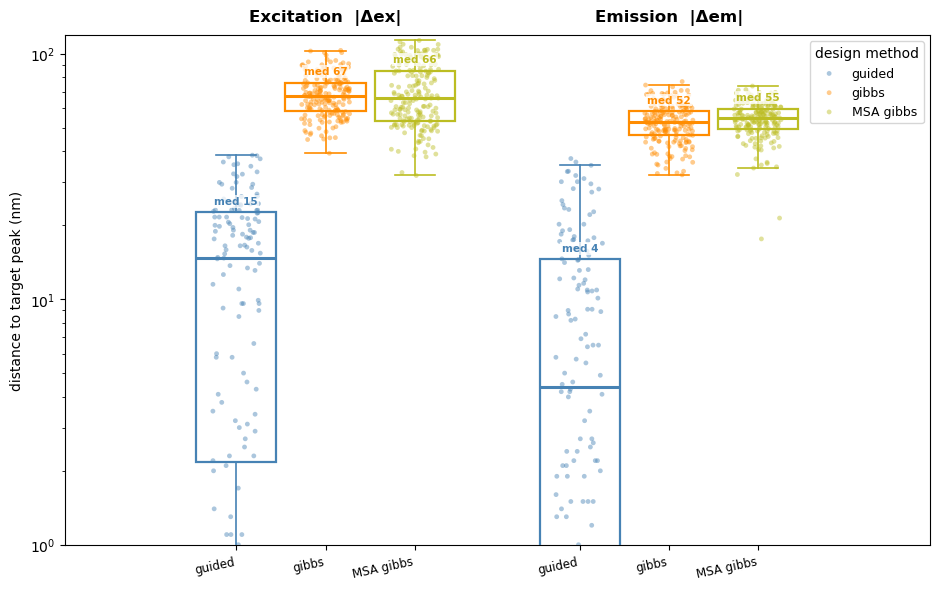

In [2]:
methods = [("guided", df, "steelblue"), ("gibbs", dfg, "darkorange"),
           ("MSA gibbs", dfmg, "#bcbd22")]
peaks = [("Excitation  |\u0394ex|", "pred_ex", "target_ex"),
         ("Emission  |\u0394em|", "pred_em", "target_em")]
rng = np.random.default_rng(0)
# evenly spaced offsets so the group scales with however many methods are listed above
_off = np.linspace(-0.26, 0.26, len(methods)) if len(methods) > 1 else np.zeros(1)
_bw = 0.9 * (_off[1] - _off[0]) if len(methods) > 1 else 0.3

fig, ax = plt.subplots(figsize=(9.5, 6))
tick_x, tick_lab = [], []
stats = []
for pk_i, (pk_label, pcol, tcol) in enumerate(peaks):
    for m_i, (mname, d, color) in enumerate(methods):
        fin = best_per_trial(d)   # each trial's best round (min surrogate peak_err)
        dist = (fin[pcol] - fin[tcol]).abs().to_numpy()
        cx = pk_i + _off[m_i]
        # boxplot with TRANSPARENT facecolor (edges/median in the method colour)
        ax.boxplot([dist], positions=[cx], widths=_bw, showfliers=False, patch_artist=True,
                   boxprops=dict(facecolor="none", edgecolor=color, linewidth=1.6),
                   medianprops=dict(color=color, linewidth=2.2),
                   whiskerprops=dict(color=color, linewidth=1.2),
                   capprops=dict(color=color, linewidth=1.2), zorder=3)
        # stripplot: jittered individual designs over the box
        x = cx + rng.uniform(-0.3 * _bw, 0.3 * _bw, size=len(dist))
        ax.scatter(x, dist, s=12, c=color, alpha=0.45, edgecolor="none",
                   label=mname if pk_i == 0 else None, zorder=4)
        med = float(np.median(dist))
        # above the box rather than on the median line, which the strip points obscured
        ax.text(cx, float(np.percentile(dist, 75)) * 1.06, f"med {med:.0f}", ha="center",
                va="bottom", fontsize=7.5, fontweight="bold", color=color, zorder=7,
                bbox=dict(fc="white", ec="none", alpha=0.75, pad=1.0))
        tick_x.append(cx); tick_lab.append(mname)
        stats.append((pk_label.split()[0], mname, len(dist), med,
                      float(np.mean(dist)), float(np.percentile(dist, 90))))

ax.set_xticks(tick_x); ax.set_xticklabels(tick_lab, fontsize=8.5, rotation=12, ha="right")
for pk_i, (pk_label, _, _) in enumerate(peaks):
    ax.text(pk_i, 1.02, pk_label, ha="center", va="bottom", fontsize=12,
            fontweight="bold", transform=ax.get_xaxis_transform())
ax.axhline(0, color="0.6", lw=0.8)
ax.set_ylabel("distance to target peak (nm)")
ax.set_ylim(bottom=1)
ax.set_yscale("log")
ax.legend(title="design method", fontsize=9, loc="upper right", frameon=True)
ax.margins(x=0.08)
fig.tight_layout()
fig.savefig(FIGDIR / "campaign_peak_distance_strip.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_peak_distance_strip.png\n")
print(f"{'peak':12}{'method':11}{'n':>5}{'median':>9}{'mean':>8}{'p90':>8}")
for pk, mn, n, md, me, p9 in stats:
    print(f"{pk:12}{mn:11}{n:>5}{md:>9.1f}{me:>8.1f}{p9:>8.1f}")
plt.show()

## Convergence — surrogate MAE vs iteration round

For each method, plot the surrogate MAE to target (`½(|Δex| + |Δem|)` = `peak_err`) against the
iteration round. At every round a single **unfilled boxplot** (`facecolor='none'`) summarizes the
distribution pooled across **all** shown designs; a **connected median** line and a **connected
minimum** line track the round-over-round trend. Every **design attempt** (one trial's trajectory) is
also overlaid faintly in its **pair's color** (round 0 is the shared scaffold starting point).

Tune `N_PAIRS_SHOW` / `N_TRIALS_SHOW` below to control which designs are pooled and overlaid.

**Expect the MSA-Gibbs panel to be flat, and read that as a property rather than a failure.** A PSSM
is context-independent: unlike ESM-2's masked-LM conditional it does not change as the sequence is
edited, so every round re-draws each editable position independently from the same fixed
distribution. Round 3 is an independent sample, not a refinement of round 2 — the chain has no
memory to converge with. Only its final distribution is meaningful.

saved figures/campaign_convergence_guided.png


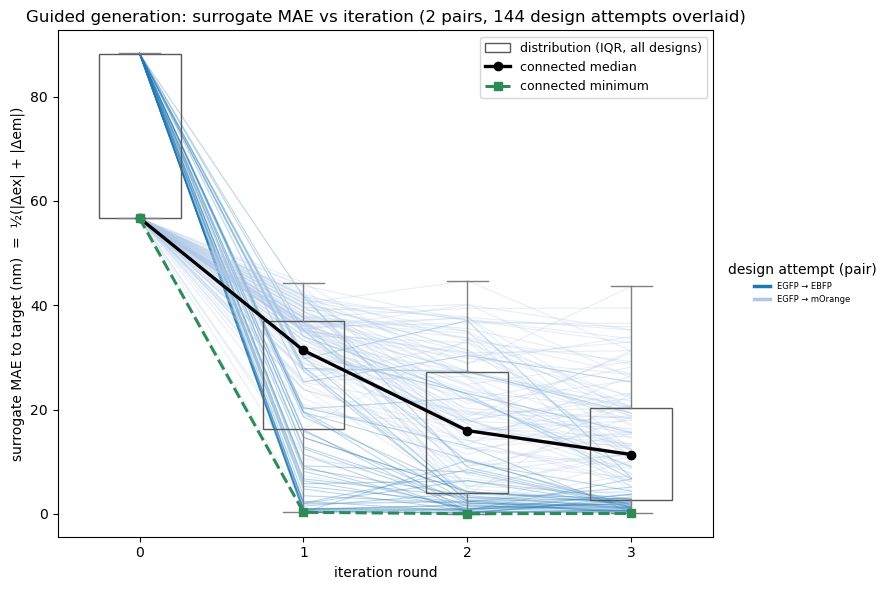

saved figures/campaign_convergence_gibbs.png


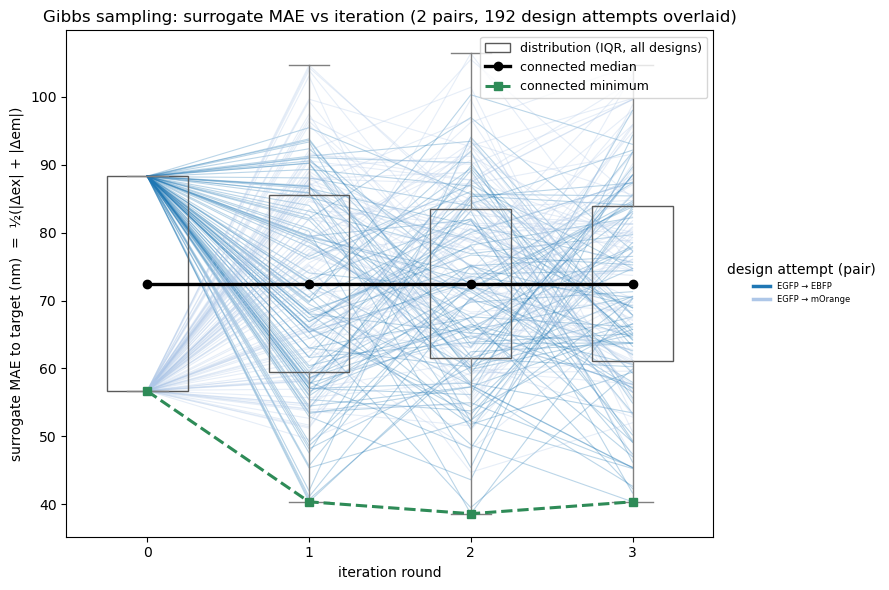

saved figures/campaign_convergence_msa_gibbs.png


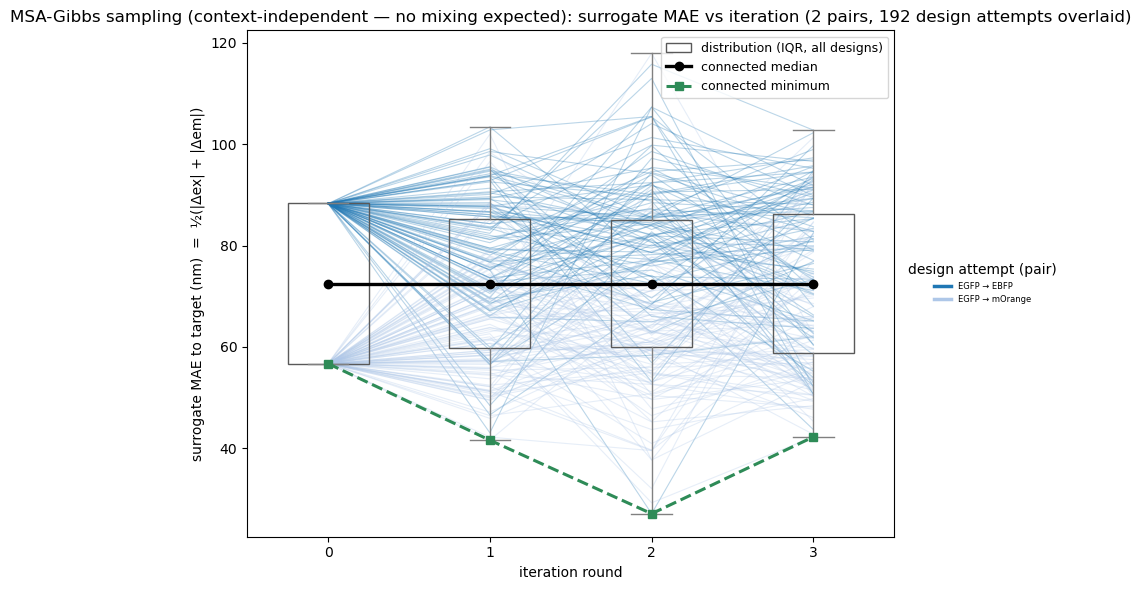

In [3]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---- tune which designs go into the aggregate distribution ------------------------
N_PAIRS_SHOW = 2         # number of scaffold->target pairs pooled into the boxplots
N_TRIALS_SHOW = None     # trials per pair pooled; None = all trials
# ----------------------------------------------------------------------------------


def plot_convergence(d, method_name, fname, n_pairs=N_PAIRS_SHOW, n_trials=N_TRIALS_SHOW):
    rmax = int(d["round"].max())
    rounds = list(range(rmax + 1))
    ps = d.groupby("pair")["scaffold_idx"].first().index.tolist()[:n_pairs]

    cmap = plt.get_cmap("tab20")
    pair_color = {p: cmap(i % 20) for i, p in enumerate(ps)}

    sub = d[d["pair"].isin(ps)].copy()
    if n_trials is not None:
        sub = sub[sub["trial"] < n_trials]

    # one aggregate distribution per round, pooled across ALL shown designs
    box_data = [sub.loc[sub["round"] == r, "peak_err"].to_numpy() for r in rounds]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.boxplot(box_data, positions=rounds, widths=0.5, showfliers=False, patch_artist=True,
               zorder=4, boxprops=dict(facecolor="none", edgecolor="0.35"),
               medianprops=dict(color="none"), whiskerprops=dict(color="0.5"),
               capprops=dict(color="0.5"))

    # overlay each individual design attempt (one trial's trajectory), colored by pair
    n_shown = 0
    for p in ps:
        for tr, gt in sub[sub["pair"] == p].groupby("trial"):
            gt = gt.sort_values("round")
            ax.plot(gt["round"], gt["peak_err"], "-", color=pair_color[p],
                    alpha=0.3, lw=0.8, zorder=2)
            n_shown += 1

    # connected median and connected minimum across rounds (over all pooled designs)
    meds = [float(np.median(b)) for b in box_data]
    mins = [float(np.min(b)) for b in box_data]
    ax.plot(rounds, meds, "-o", color="black", lw=2.4, ms=6, zorder=6)
    ax.plot(rounds, mins, "--s", color="seagreen", lw=2.2, ms=6, zorder=6)

    ax.set_xticks(rounds); ax.set_xlim(-0.5, rmax + 0.5)
    ax.set_xlabel("iteration round")
    ax.set_ylabel("surrogate MAE to target (nm)  =  \u00bd(|\u0394ex| + |\u0394em|)")
    ax.set_title(f"{method_name}: surrogate MAE vs iteration "
                 f"({len(ps)} pairs, {n_shown} design attempts overlaid)")

    style_leg = ax.legend([Patch(facecolor="none", edgecolor="0.35"),
                           Line2D([0], [0], color="black", lw=2.4, marker="o"),
                           Line2D([0], [0], color="seagreen", lw=2.2, ls="--", marker="s")],
                          ["distribution (IQR, all designs)", "connected median", "connected minimum"],
                          loc="upper right", fontsize=9, frameon=True)
    ax.add_artist(style_leg)
    ax.legend([Line2D([0], [0], color=pair_color[p], lw=2.5) for p in ps], ps,
              fontsize=6, ncol=1, loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False, title="design attempt (pair)")
    fig.tight_layout()
    fig.savefig(FIGDIR / fname, dpi=130, bbox_inches="tight")
    print("saved", FIGDIR / fname)
    plt.show()


plot_convergence(df, "Guided generation", "campaign_convergence_guided.png")
plot_convergence(dfg, "Gibbs sampling", "campaign_convergence_gibbs.png")
# MSA-gibbs is expected to be FLAT, and that is the point: a PSSM is context-independent, so unlike
# ESM-2's conditional it does not change as the sequence is edited. Each round re-draws every
# editable position independently from the same fixed distribution -- round 3 is an independent
# sample, not a refinement of round 2, so the chain has no memory to converge with.
plot_convergence(dfmg, "MSA-Gibbs sampling (context-independent \u2014 no mixing expected)",
                 "campaign_convergence_msa_gibbs.png")

## Are the designs in-distribution for the GFP-family DMS brightness models?

The DMS brightness models were trained on ESM-2 650M embeddings of large deep-mutational-scanning
libraries built on **four GFP scaffolds**: **avGFP** (Sarkisyan) plus the three orthologs
**amacGFP**, **cgreGFP**, and **ppluGFP**. To judge whether our EGFP designs are
**in-distribution (ID)** or **out-of-distribution (OOD)**, we compare embeddings directly:

- **DMS clouds** — **max-pooled** ESM-2 embeddings of **1,000 randomly sampled sequences per
  scaffold** (4,000 total), read from the cached per-residue embeddings
  (`avgfp_dms` → `esm_residue_fp16.npy`; `amacGFP`/`cgreGFP`/`ppluGFP` → `ortho_gfp_dms_esm_residue_fp16.npy`).
  Max-pool matches the CNN(1)-max model's own pooling, so this is the representation closest to what
  the models actually key on.
- **Designs** — the unique designed sequences from all four families of strategy (guided, gibbs,
  MSA guide, MSA gibbs; all iterations), reframed to the DMS window (`seq[3:238]`) and **max-pooled**
  the same way, so the comparison is apples-to-apples.

We (1) project everything onto PCA axes fit on the **combined 4-scaffold cloud** so you can see which
scaffold family each design lands in, and (2) quantify OOD-ness with the distance from each design to
its nearest DMS neighbor (standardized embedding space) versus the DMS's own internal
nearest-neighbor distances. Designs sitting outside the clouds / with large NN distances are
extrapolations the brightness models cannot be trusted on.

In [4]:
# Build max-pooled ESM-2 embeddings for 1k sequences per GFP scaffold + the (reframed) unique designs.
import sys, torch
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# locate repo root (folder holding the GFP DMS cache) whether cwd is the campaign dir or the repo
HERE = Path.cwd()
REPO = next((b for b in [HERE, *HERE.parents]
             if any((b / d / "DMS_data").exists() for d in ("avGFP_DMS", "GFP_DMS"))), HERE.parent)
DMSD = next(REPO / d / "DMS_data" for d in ("avGFP_DMS", "GFP_DMS")
            if (REPO / d / "DMS_data").exists())
sys.path.insert(0, str(REPO / "esm2_design"))
import peak_models as pm
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("repo:", REPO, "| DMS:", DMSD.name, "| device:", dev)

# ---- DMS clouds: MAX-pool 1,000 random seqs from EACH of the 4 GFP scaffolds (cache to disk) ----
# avGFP lives in its own cache; amacGFP/cgreGFP/ppluGFP share the "ortho" cache. Each cache row is
# aligned 1:1 with its CSV, so we sample CSV row-indices and read those rows from the .npy.
N_PER = 10000
SCAFFOLDS = ["avGFP", "amacGFP", "cgreGFP", "ppluGFP"]
SRC = {  # scaffold -> (sequences csv, residue-embedding .npy, residue-length .npy, brightness col)
    "avGFP":   ("avgfp_dms_sequences.csv",     "esm_residue_fp16.npy",            "esm_residue_len.npy",            "logMedianBrightness"),
    "amacGFP": ("ortho_gfp_dms_sequences.csv", "ortho_gfp_dms_esm_residue_fp16.npy", "ortho_gfp_dms_esm_residue_len.npy", "logBrightness"),
    "cgreGFP": ("ortho_gfp_dms_sequences.csv", "ortho_gfp_dms_esm_residue_fp16.npy", "ortho_gfp_dms_esm_residue_len.npy", "logBrightness"),
    "ppluGFP": ("ortho_gfp_dms_sequences.csv", "ortho_gfp_dms_esm_residue_fp16.npy", "ortho_gfp_dms_esm_residue_len.npy", "logBrightness"),
}
MP_CACHE = DMSD / f"esm_maxpool_4scaffold_{N_PER//1000}k.npz"

def _maxpool_rows(Hpath, Lpath, rows):
    H = np.load(Hpath, mmap_mode="r"); Ls = np.load(Lpath).astype(int)
    out = np.zeros((len(rows), H.shape[2]), np.float32)
    for t, i in enumerate(rows):
        n = int(Ls[i]); r = np.asarray(H[i]).astype(np.float32)
        out[t] = r[:n].max(0) if n else 0.0
    return out

if MP_CACHE.exists():
    _z = np.load(MP_CACHE, allow_pickle=True)
    mp, scaf_lab, y_dms = _z["mp"], _z["scaf"].astype(str), _z["y"]
    print(f"loaded cached 4-scaffold max-pool {mp.shape}")
else:
    rng0 = np.random.default_rng(0)
    parts, labs, ys = [], [], []
    for s in SCAFFOLDS:
        csv, emb, lenf, ycol = SRC[s]
        d = pd.read_csv(DMSD / csv)
        idx = d.index[d["scaffold"] == s].to_numpy() if "scaffold" in d.columns else d.index.to_numpy()
        take = np.sort(rng0.choice(idx, size=min(N_PER, len(idx)), replace=False))
        parts.append(_maxpool_rows(DMSD / emb, DMSD / lenf, take))
        labs.append(np.full(len(take), s)); ys.append(d[ycol].to_numpy()[take])
        print(f"  {s}: max-pooled {len(take)} / {len(idx)} available")
    mp = np.concatenate(parts); scaf_lab = np.concatenate(labs); y_dms = np.concatenate(ys)
    np.savez(MP_CACHE, mp=mp, scaf=scaf_lab, y=y_dms)
    print(f"cached 4-scaffold max-pool {mp.shape} -> {MP_CACHE.name}")

# per-scaffold consensus of the avGFP DMS = avGFP parent (235 aa) reference point
_dms_av = pd.read_csv(DMSD / "avgfp_dms_sequences.csv")
_arr = np.array([list(s) for s in _dms_av["mutatedSequence"].values])
PARENT235 = "".join(Counter(_arr[:, j]).most_common(1)[0][0] for j in range(_arr.shape[1]))

# ---- Designs: unique sequences (guided + gibbs + MSA-guided, iterations >=1), reframed to the
#      DMS window.
#      The MSA-guided strategy was run as a 125-cell lambda sweep (12 trials x 3 rounds per cell)
#      rather than at a single setting, so we POOL EVERY CELL: its design pool is everything the
#      family-profile proposal produced anywhere in the sweep. Trial ids repeat across cells, so
#      they are namespaced by cell to stay unique for per-trial groupings.
#      MSA_BEST is the single best cell, kept separately for the tuned-setting bar chart at the
#      bottom of the notebook. See msa-guided/README.md. ----
_mcands = [Path("msa-guided/designs"), Path("design-campaign-EGFP/msa-guided/designs"),
           Path.cwd() / "msa-guided" / "designs"]
MSA = next((c for c in _mcands if c.exists()), None)
assert MSA is not None, "could not find msa-guided/designs"
MSA_BEST = MSA / "lam-ex2_lam-em2_lam-bright4_lam-edit0"

def msa_sweep_csvs(target=None):
    return sorted(MSA.glob(f"*/design_EGFP-{target or '*'}.csv"))

def load_msa_sweep():
    fs = msa_sweep_csvs()
    d = pd.concat([pd.read_csv(f).assign(source=f.parent.name) for f in fs], ignore_index=True)
    d["pair"] = d["scaffold_name"] + " \u2192 " + d["target_name"]
    d["trial"] = d["source"] + "#" + d["trial"].astype(str)
    return d

dfm = load_msa_sweep()

alld = pd.concat([df.assign(_method="guided"), dfg.assign(_method="gibbs"),
                  dfm.assign(_method="msa"), dfmg.assign(_method="msa-gibbs")], ignore_index=True)
alld = alld[alld["round"] >= 1]
uniq = alld.drop_duplicates("designed_seq").copy()
print(f"design pool (unique, round>=1): guided {df.designed_seq.nunique()} | "
      f"gibbs {dfg.designed_seq.nunique()} | msa-gibbs {dfmg.designed_seq.nunique()} | "
      f"msa {dfm[dfm['round'] >= 1].designed_seq.nunique()} "
      f"pooled over {dfm.source.nunique()} sweep cells")
egfp = df["scaffold_seq"].iloc[0]
egfp235 = egfp[3:238]
uniq["seq235"] = uniq["designed_seq"].str[3:238]
uniq["nmut"] = uniq["seq235"].apply(lambda s: sum(a != b for a, b in zip(s, egfp235)))
print(f"unique designs: {len(uniq)} | mutation load vs EGFP: {uniq['nmut'].min()}-{uniq['nmut'].max()}")

@torch.no_grad()
def _max_embed_gpu(seqs, bs=64):
    """Masked max-pool of ESM-2 650M per-residue embeddings -> (n, 1280) (matches CNN(1)-max)."""
    out = []
    for i in range(0, len(seqs), bs):
        Hh, mm = pm.resid_embed(list(seqs[i:i + bs]), dev)
        out.append(pm.masked_pool(Hh, mm, "max").float().cpu().numpy())
    return np.concatenate(out)

# The design CSVs record pred_ex/pred_em/pred_bright but NOT this embedding -- it exists only to
# place designs on the DMS PCA and to compute the ID test, so it has to be built here. The same
# sequences are embedded by the per-strategy cell below and by make_shortlist_case.py, and the MSA
# sweep alone contributes ~5.4k designs, so cache on the sequence: each is embedded once ever.
sys.path.insert(0, str(DESIGNS.parent.parent))
from embed_cache import MaxPoolCache
max_embed = MaxPoolCache(DESIGNS.parent.parent / ".embed_cache" / "maxpool_esm2_650M.npz",
                         _max_embed_gpu)

dmp = max_embed(uniq["seq235"].tolist())             # designs
ref = max_embed([egfp235, PARENT235])                # EGFP scaffold + avGFP parent
egfp_mp, parent_mp = ref[0:1], ref[1:2]
print("design embeddings:", dmp.shape)

# ---- PCA fit on the COMBINED 4-scaffold cloud; project everything ----
mu, sd = mp.mean(0), mp.std(0) + 1e-6
Z = (mp - mu) / sd
pca = PCA(n_components=2, random_state=0).fit(Z)
P_dms = pca.transform(Z)
P_des = pca.transform((dmp - mu) / sd)
P_egfp = pca.transform((egfp_mp - mu) / sd)
P_par = pca.transform((parent_mp - mu) / sd)

# ---- all 758 curated "true" FPs (dataset pipeline): max-pool the precomputed ESM-2 residue
#      embeddings (aligned 1:1 with peaks_assignments.csv) and project onto the SAME PCA ----
CUR = REPO / "dataset_pipeline" / "data" / "peak" / "curated"
_fp_assign = pd.read_csv(CUR / "peaks_assignments.csv")
fp_mp = _maxpool_rows(CUR / "esm_residue_fp16.npy", CUR / "esm_residue_len.npy",
                      np.arange(len(_fp_assign)))
P_fp = pca.transform((fp_mp - mu) / sd)
print(f"curated true FPs: {P_fp.shape[0]} ESM-2 max-pool embeddings projected onto the PCA")

# ---- KDE density contours (replaces dense per-scaffold scatter when there are too many points) ----
from scipy.stats import gaussian_kde

def kde_contours(ax, P2, color, label=None, n_levels=9, grid=160, thresh=0.08, pad=0.25,
                 zorder=1):
    """Draw a filled outer blob + several light density contour lines for a 2D point cloud.
    The grid is padded beyond the data range (pad = fraction of each axis span) so the outer
    contours CLOSE instead of being clipped at the point bounding box."""
    x, y = P2[:, 0], P2[:, 1]
    k = gaussian_kde(np.vstack([x, y]))
    xpad = (x.max() - x.min()) * pad + 1e-6; ypad = (y.max() - y.min()) * pad + 1e-6
    xs = np.linspace(x.min() - xpad, x.max() + xpad, grid)
    ys = np.linspace(y.min() - ypad, y.max() + ypad, grid)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = k(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)
    zmax = ZZ.max()
    ax.contourf(XX, YY, ZZ, levels=[zmax * thresh, zmax], colors=[color], alpha=0.08, zorder=zorder)
    ax.contour(XX, YY, ZZ, levels=np.linspace(zmax * thresh, zmax, n_levels), colors=color,
               linewidths=0.6, alpha=0.45, zorder=zorder)
    if label:
        ax.plot([], [], color=color, lw=3, alpha=0.55, label=label)   # proxy handle for the legend

# ---- OOD metric: NN distance (standardized space) design->DMS vs DMS internal ----
rng = np.random.default_rng(0)
Zd = (dmp - mu) / sd
nn = NearestNeighbors(n_neighbors=1).fit(Z)          # reference = the full 4k DMS sample
d_des, _ = nn.kneighbors(Zd)                          # each design -> nearest DMS (any scaffold)
nn2 = NearestNeighbors(n_neighbors=2).fit(Z)
d_dms, _ = nn2.kneighbors(Z)                          # DMS internal (2nd nbr excludes self)
d_des, d_dms = d_des.ravel(), d_dms[:, 1]
p99 = np.percentile(d_dms, 99)
frac_ood = float((d_des > p99).mean())

# which scaffold family is each design nearest to?
near_by_scaf = {}
for s in SCAFFOLDS:
    m = scaf_lab == s
    near_by_scaf[s] = NearestNeighbors(n_neighbors=1).fit(Z[m]).kneighbors(Zd)[0].ravel()
nearest_scaf = np.array(SCAFFOLDS)[np.argmin(np.column_stack([near_by_scaf[s] for s in SCAFFOLDS]), 1)]

print(f"\nNN-distance (standardized embedding):")
print(f"  DMS internal   median {np.median(d_dms):.2f}   99th pct {p99:.2f}")
print(f"  designs->DMS   median {np.median(d_des):.2f}   range {d_des.min():.2f}-{d_des.max():.2f}")
print(f"  designs beyond DMS 99th-pct NN distance: {frac_ood:.1%}")
print("  nearest-scaffold family for designs:",
      {s: int((nearest_scaf == s).sum()) for s in SCAFFOLDS})
print(" ", max_embed)

repo: /home/ubuntu/spectrum-to-fp-design | DMS: DMS_data | device: cuda
loaded cached 4-scaffold max-pool (40000, 1280)


design pool (unique, round>=1): guided 433 | gibbs 289 | msa-gibbs 289 | msa 5448 pooled over 125 sweep cells
unique designs: 6456 | mutation load vs EGFP: 0-25
design embeddings: (6456, 1280)


curated true FPs: 758 ESM-2 max-pool embeddings projected onto the PCA



NN-distance (standardized embedding):
  DMS internal   median 13.06   99th pct 30.21
  designs->DMS   median 28.60   range 0.06-74.39
  designs beyond DMS 99th-pct NN distance: 40.6%
  nearest-scaffold family for designs: {'avGFP': 6456, 'amacGFP': 0, 'cgreGFP': 0, 'ppluGFP': 0}
  MaxPoolCache(maxpool_esm2_650M.npz: 7316 cached, 6458 hits / 0 embedded this session)


saved figures/campaign_dms_ood_4scaffold.png


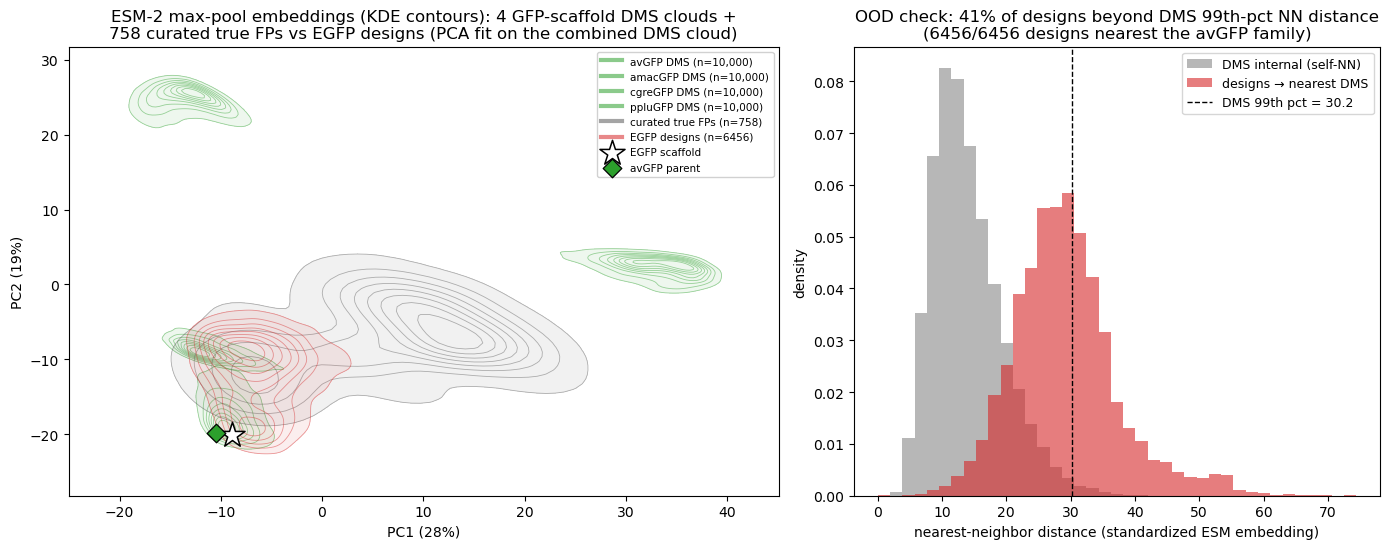

In [5]:
# Left: PCA of the 4 GFP-scaffold DMS clouds vs designs. Right: OOD NN-distance histograms.
fig, (axP, axH) = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1.35, 1]})

# --- PCA: KDE density contours per DMS scaffold (1k each) + 758 true FPs + designs by mutation load ---
SCAF_COLORS = {s: "#2ca02c" for s in ("avGFP", "amacGFP", "cgreGFP", "ppluGFP")}  # all GFP DMS = green
for s in SCAFFOLDS:
    m = scaf_lab == s
    kde_contours(axP, P_dms[m], SCAF_COLORS[s], label=f"{s} DMS (n={int(m.sum()):,})")
kde_contours(axP, P_fp, "0.35", label=f"curated true FPs (n={P_fp.shape[0]})", zorder=2)
kde_contours(axP, P_des, "#d62728", label=f"EGFP designs (n={P_des.shape[0]})", zorder=3)
axP.scatter(*P_egfp[0], marker="*", s=360, c="w", edgecolor="k", linewidth=1.1,
            zorder=4, label="EGFP scaffold")
axP.scatter(*P_par[0], marker="D", s=90, c="#2ca02c", edgecolor="k", linewidth=0.9,
            zorder=4, label="avGFP parent")
axP.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axP.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axP.set_title("ESM-2 max-pool embeddings (KDE contours): 4 GFP-scaffold DMS clouds +\n"
              "758 curated true FPs vs EGFP designs (PCA fit on the combined DMS cloud)")
_focus = np.vstack([P_dms, P_des, P_egfp, P_par])     # zoom to the DMS+design region (true FPs may clip)
_mx = (_focus[:, 0].max() - _focus[:, 0].min()) * 0.08
_my = (_focus[:, 1].max() - _focus[:, 1].min()) * 0.08
axP.set_xlim(_focus[:, 0].min() - _mx, _focus[:, 0].max() + _mx)
axP.set_ylim(_focus[:, 1].min() - _my, _focus[:, 1].max() + _my)
axP.legend(loc="best", fontsize=7.5, framealpha=0.9)

# --- NN-distance histograms (OOD): DMS internal vs designs, per-scaffold nearest overlaid ---
lo = min(d_dms.min(), d_des.min()); hi = max(d_dms.max(), d_des.max())
bins = np.linspace(lo, hi, 40)
axH.hist(d_dms, bins=bins, density=True, color="0.6", alpha=0.7, label="DMS internal (self-NN)")
axH.hist(d_des, bins=bins, density=True, color="#d62728", alpha=0.6, label="designs \u2192 nearest DMS")
axH.axvline(p99, ls="--", color="k", lw=1, label=f"DMS 99th pct = {p99:.1f}")
axH.set_xlabel("nearest-neighbor distance (standardized ESM embedding)")
axH.set_ylabel("density")
_topscaf, _topn = Counter(nearest_scaf).most_common(1)[0]
axH.set_title(f"OOD check: {frac_ood:.0%} of designs beyond DMS 99th-pct NN distance\n"
              f"({_topn}/{len(d_des)} designs nearest the {_topscaf} family)")
axH.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIGDIR / "campaign_dms_ood_4scaffold.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_dms_ood_4scaffold.png")
plt.show()

## In-distribution, per strategy — design contour + top-10 shortlist

One panel **per strategy × target** (10 total), each dropping that strategy onto the *same* 4-scaffold DMS
embedding space (same fitted PCA, standardization, and nearest-neighbor reference). Each panel shows
the four **GFP-DMS clouds** (green KDE contours) as shared background, the strategy's **full design
pool** as a KDE contour, and its **top-10 shortlist** designs as a scatter — all coloured by target
(**mOrange = orange**, **EBFP = blue**). The final panel gives the **OOD metric**: the nearest-neighbor
distance distribution for each strategy (distinct colours) vs the DMS internal self-NN, with the 99th
-pct threshold. The idea: strategies whose designs (and especially their shortlisted top-10) sit
inside the green clouds are in-distribution, so the brightness classifier's calls on them are more
trustworthy; strategies that extrapolate far out (high % OOD) are riskier.

**MSA guide** (both targets) is the newest strategy: the 763-sequence family alignment replaces
ESM-2 as the proposal distribution, and residues the family never uses at a window position are
removed from the alphabet outright (see [`msa-guided/README.md`](msa-guided/README.md)). It was run
as a **125-cell λ sweep** rather than at one setting, and its pool here is the **union of all 125
cells** — every design the family-profile proposal produced anywhere in the sweep. Read its
contour as "where this strategy explores across its whole λ grid", which is a broader region than
the single-setting strategies cover, and note that its top-10 is selected from ~2.6–2.8k unique
designs against ~288 for the others.

**MSA gibbs** (both targets) is its unguided control — the same family profile with the surrogate
removed from selection (see [`msa-gibbs/README.md`](msa-gibbs/README.md)). Together with plain
**gibbs** it makes the proposal effect readable directly off this figure: both unguided strategies
are target-free, so each contributes one 288-design pool that appears twice (once per target, with
only the shortlist selection differing). Neither produces a single predicted-bright design, so their
shortlists are the plain closest-10 rather than the ID-and-bright filter the "- bright" strategies
use. Comparing their two contours isolates what swapping ESM-2 for the family profile buys before
any steering is added.

gibbs                      (mOrange) pool n= 288 | top-10 located 10 | NN-dist med 42.7 | OOD(>30.2) 100%
gibbs                      (EBFP) pool n= 288 | top-10 located 10 | NN-dist med 42.7 | OOD(>30.2) 100%
MSA gibbs                  (mOrange) pool n= 288 | top-10 located 10 | NN-dist med 35.2 | OOD(>30.2) 92%


MSA gibbs                  (EBFP) pool n= 288 | top-10 located 10 | NN-dist med 35.2 | OOD(>30.2) 92%
spectra guide              (mOrange) pool n= 288 | top-10 located 10 | NN-dist med 40.0 | OOD(>30.2) 98%


constrained spectra guide  (mOrange) pool n= 288 | top-10 located 10 | NN-dist med 34.6 | OOD(>30.2) 85%
DMS guide - bright         (mOrange) pool n= 287 | top-10 located 10 | NN-dist med 28.9 | OOD(>30.2) 32%
DMS guide - bright         (EBFP) pool n= 284 | top-10 located 10 | NN-dist med 29.3 | OOD(>30.2) 38%


MSA guide - bright         (mOrange) pool n=2635 | top-10 located 10 | NN-dist med 27.3 | OOD(>30.2) 29%


MSA guide - bright         (EBFP) pool n=2835 | top-10 located 10 | NN-dist med 27.1 | OOD(>30.2) 31%
  MaxPoolCache(maxpool_esm2_650M.npz: 7316 cached, 14227 hits / 0 embedded this session)


saved figures/campaign_ood_per_strategy.png


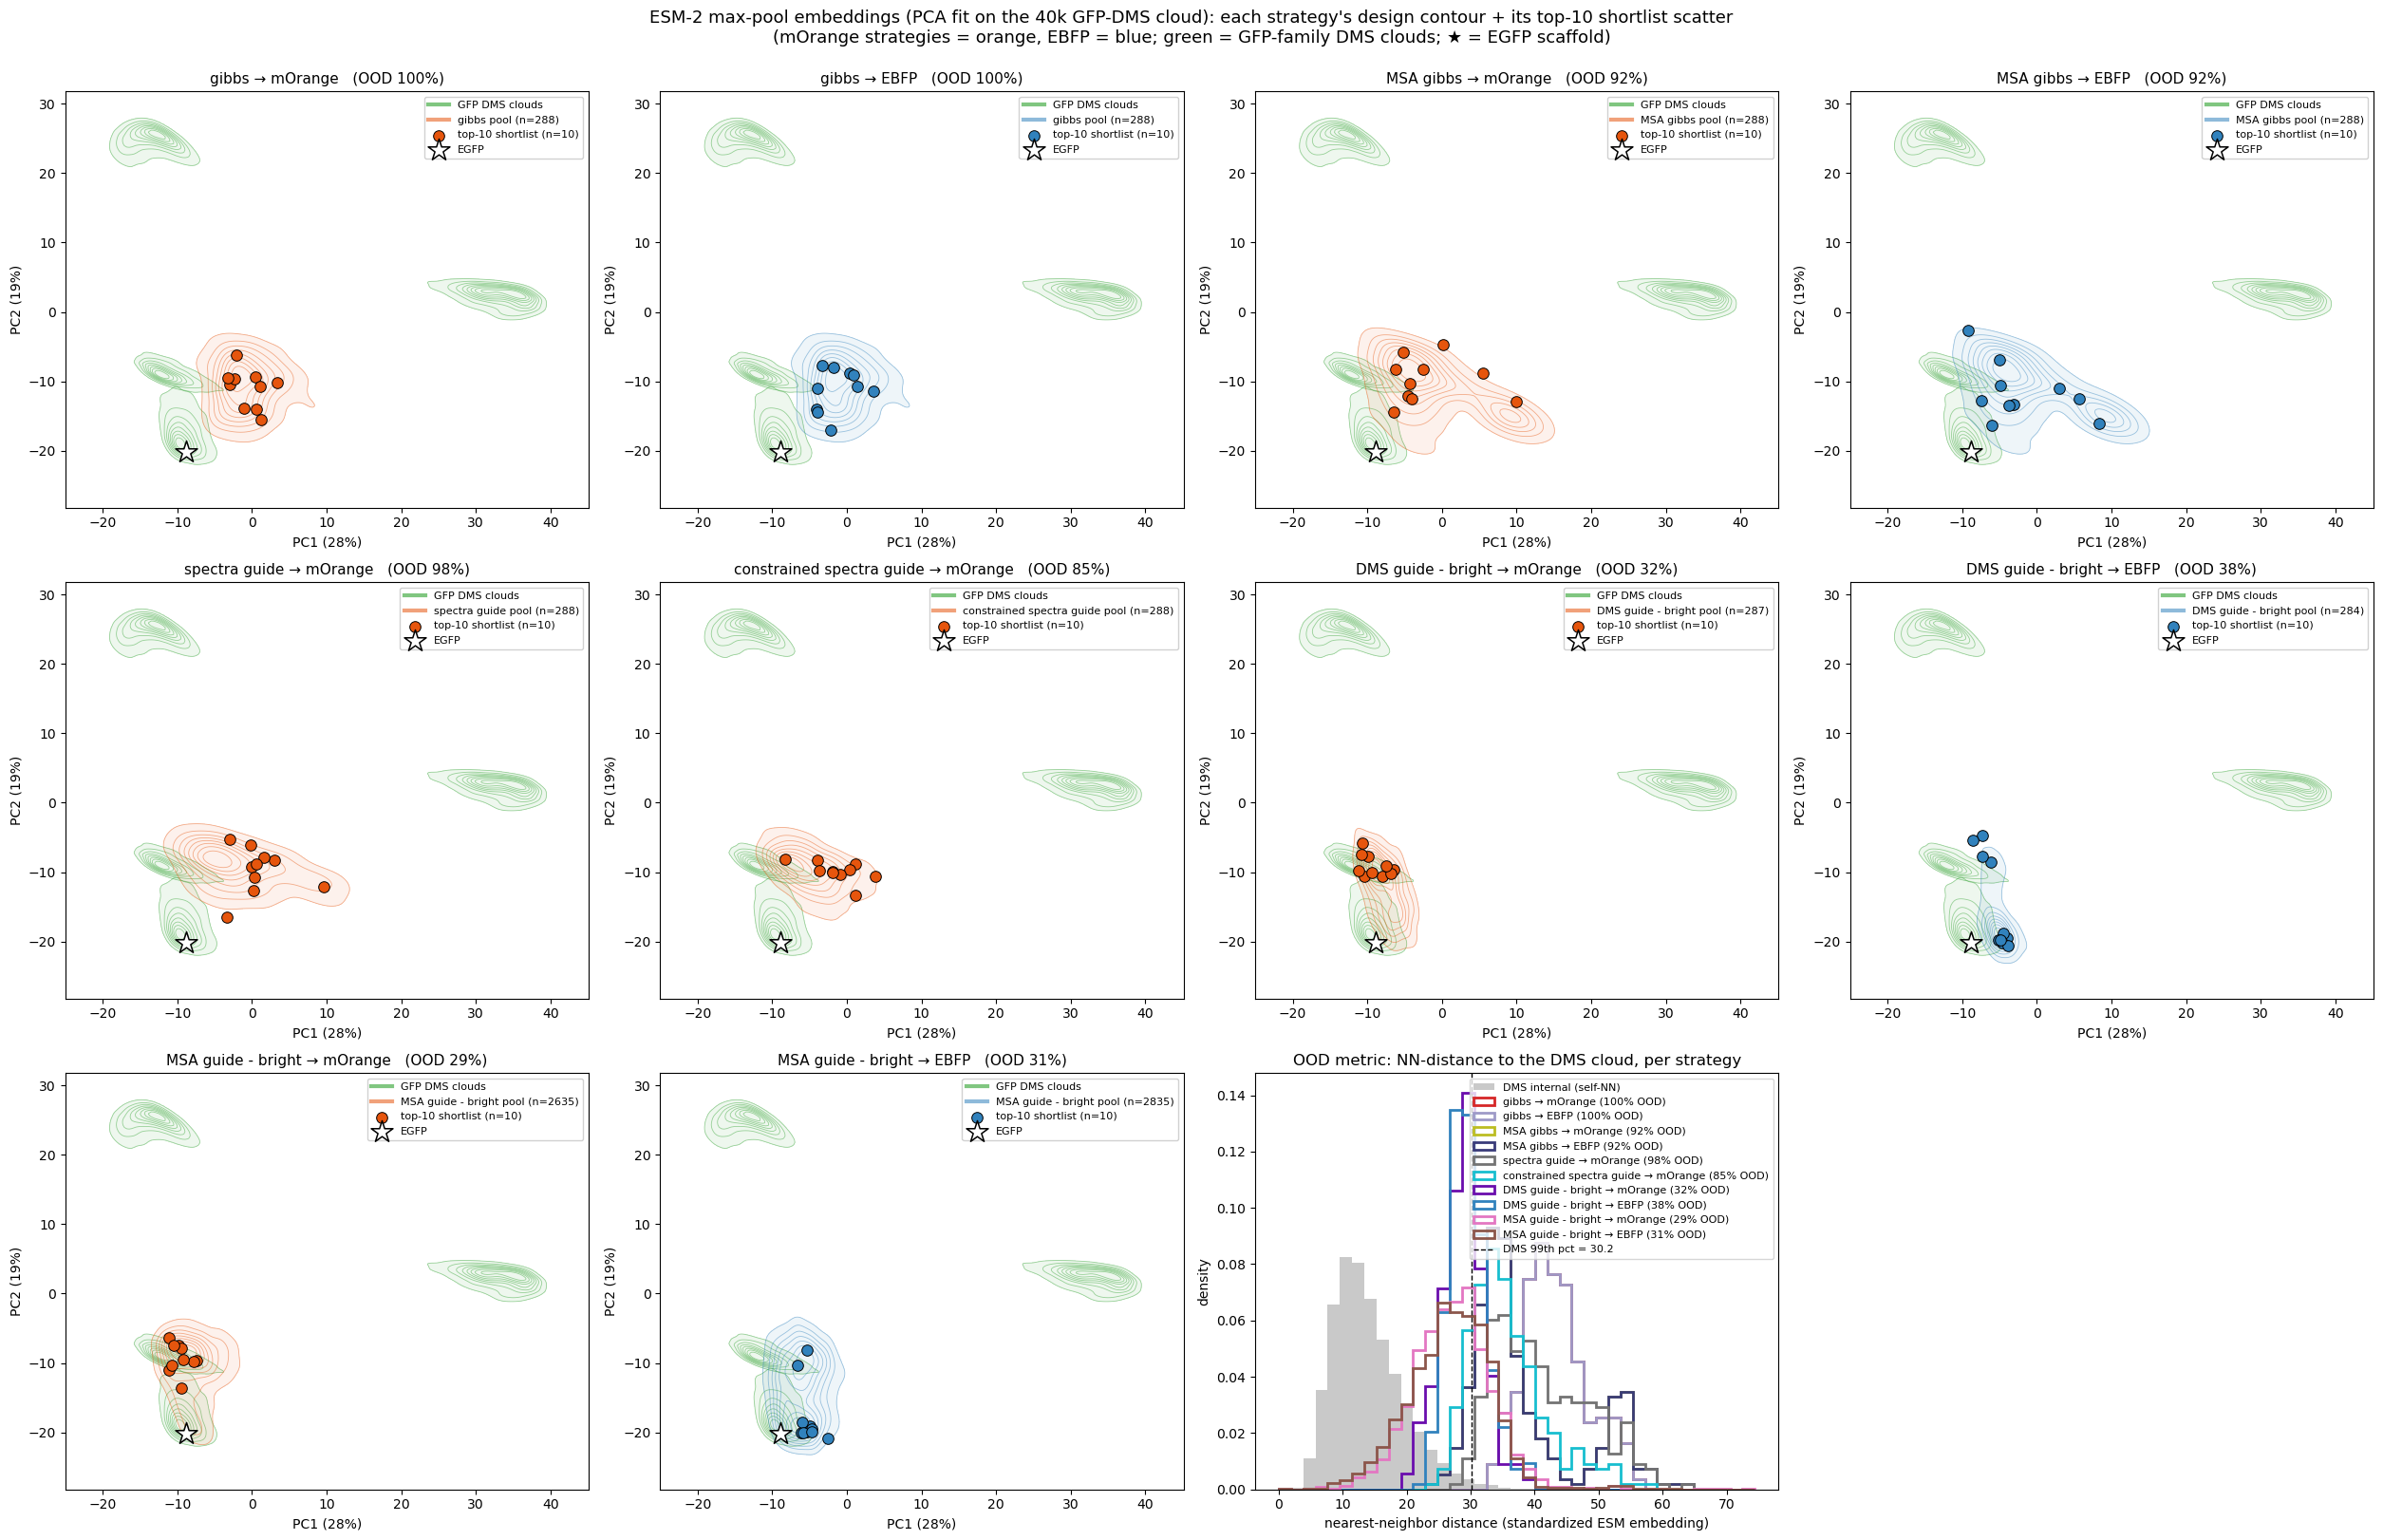

In [6]:
# ---- Per-strategy in-distribution panels (one panel per strategy + a final OOD panel, laid out 4
#      to a row): each strategy panel draws the 4 GFP-DMS clouds (green KDE) as shared background +
#      that strategy's FULL design pool as a KDE contour + its TOP-10 shortlist designs as a scatter,
#      all coloured by TARGET (mOrange = orange, EBFP = blue). The last panel is the OOD metric:
#      nearest-neighbour distance distribution for EACH strategy (distinct colours) vs the DMS
#      internal self-NN. Reuses P_dms, P_fp, P_egfp, scaf_lab, SCAFFOLDS, SCAF_COLORS, kde_contours,
#      mu, sd, pca, nn, p99, d_dms, max_embed, GIBBS, MGIBBS, DESIGNS, MSA, FIGDIR from above.
CAMP = DESIGNS.parent.parent
SL = CAMP / "shortlists"
ORANGE, BLUE = "#e6550d", "#3182bd"
B60 = CAMP / "brightness-guided" / "guided_design" / "designs_lam-bright60_lam-edit10"
CONS = CAMP / "guided-design-constraint" / "designs_lam-edit10"
CASES = [   # (label, target, full-pool csv, shortlist xlsx, target-colour, hist-colour)
    # The two unguided (gibbs) strategies are target-free, so ONE pool of 288 designs serves both
    # targets and only the shortlist selection differs between the mOrange and EBFP rows. Neither
    # produces any predicted-bright design, so both take the plain closest-10 (an ID & bright filter
    # would return an empty pool) -- which is why their labels carry no "- bright" suffix.
    ("gibbs",                     "mOrange", GIBBS / "design_EGFP.csv",          "shortlist_mOrange_gibbs.xlsx",                      ORANGE, "#d62728"),
    ("gibbs",                     "EBFP",    GIBBS / "design_EGFP.csv",          "shortlist_EBFP_gibbs.xlsx",                         BLUE,   "#9e9ac8"),
    ("MSA gibbs",                 "mOrange", MGIBBS / "design_EGFP.csv",         "shortlist_mOrange_MSA-gibbs.xlsx",                  ORANGE, "#bcbd22"),
    ("MSA gibbs",                 "EBFP",    MGIBBS / "design_EGFP.csv",         "shortlist_EBFP_MSA-gibbs.xlsx",                     BLUE,   "#393b79"),
    ("spectra guide",             "mOrange", DESIGNS / "design_EGFP-mOrange.csv", "shortlist_mOrange_spectra-guide.xlsx",             ORANGE, "0.45"),
    ("constrained spectra guide", "mOrange", CONS / "design_EGFP-mOrange.csv",    "shortlist_mOrange_constrained-spectra-guide.xlsx", ORANGE, "#17becf"),
    ("DMS guide - bright",        "mOrange", B60 / "design_EGFP-mOrange.csv",     "shortlist_mOrange_DMS-guide.xlsx",                 ORANGE, "#6a0dad"),
    ("DMS guide - bright",        "EBFP",    B60 / "design_EGFP-EBFP.csv",        "shortlist_EBFP_DMS-guide.xlsx",                    BLUE,   "#3182bd"),
    # MSA-guided pools all 125 sweep cells (see the cell above), so its pool is ~10x deeper than the
    # single-setting strategies -- its top-10 is therefore chosen from far more candidates.
    ("MSA guide - bright",        "mOrange", msa_sweep_csvs("mOrange"),           "shortlist_mOrange_MSA-guide.xlsx",                 ORANGE, "#e377c2"),
    ("MSA guide - bright",        "EBFP",    msa_sweep_csvs("EBFP"),              "shortlist_EBFP_MSA-guide.xlsx",                    BLUE,   "#8c564b"),
]

def _pool_embed(csv):
    """csv is one file or a list of files (the MSA sweep); pool, dedupe, embed, project."""
    paths = list(csv) if isinstance(csv, list) else [csv]
    d = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    d = d[d["round"] >= 1].drop_duplicates("designed_seq").copy()
    Zx = (max_embed(d["designed_seq"].str[3:238].tolist()) - mu) / sd
    return d, pca.transform(Zx), nn.kneighbors(Zx)[0].ravel()

cases = []
for label, tgt, csv, slf, tcol, hcol in CASES:
    d, P, dist = _pool_embed(csv)
    sl = pd.read_excel(SL / slf); sl = sl[sl["role"] == "design"]
    top = d["designed_seq"].isin(set(sl["aa_sequence"])).to_numpy()   # locate the shortlist within the pool
    cases.append(dict(label=label, tgt=tgt, tcol=tcol, hcol=hcol, d=d, P=P, dist=dist,
                      Ptop=P[top], ood=float((dist > p99).mean())))
    print(f"{label:26} ({tgt}) pool n={len(d):4d} | top-10 located {int(top.sum())} | "
          f"NN-dist med {np.median(dist):.1f} | OOD(>{p99:.1f}) {(dist > p99).mean():.0%}")
print(" ", max_embed)

# zoom shared across every PCA panel (DMS + all design pools + EGFP)
_focus = np.vstack([P_dms, P_egfp] + [c["P"] for c in cases])
xmn, xmx = _focus[:, 0].min(), _focus[:, 0].max(); ymn, ymx = _focus[:, 1].min(), _focus[:, 1].max()
xpad = (xmx - xmn) * 0.08; ypad = (ymx - ymn) * 0.08

npan = len(cases) + 1                       # one panel per strategy + the OOD histogram
ncol = 4; nrow = int(np.ceil(npan / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(6.3 * ncol, 5.5 * nrow)); axes = axes.ravel()
for ax in axes[npan:]:
    ax.axis("off")
for ax, c in zip(axes[:len(cases)], cases):
    for s in SCAFFOLDS:                                       # shared green DMS background
        kde_contours(ax, P_dms[scaf_lab == s], SCAF_COLORS[s])
    ax.plot([], [], color="#2ca02c", lw=3, alpha=0.6, label="GFP DMS clouds")
    kde_contours(ax, c["P"], c["tcol"], label=f"{c['label']} pool (n={len(c['d'])})", zorder=3)
    ax.scatter(c["Ptop"][:, 0], c["Ptop"][:, 1], s=70, c=c["tcol"], edgecolor="k", linewidth=0.7,
               zorder=5, label=f"top-10 shortlist (n={len(c['Ptop'])})")
    ax.scatter(*P_egfp[0], marker="*", s=300, c="w", edgecolor="k", linewidth=1.1, zorder=6, label="EGFP")
    ax.set_title(f"{c['label']} \u2192 {c['tgt']}   (OOD {c['ood']:.0%})", fontsize=11)
    ax.set_xlim(xmn - xpad, xmx + xpad); ax.set_ylim(ymn - ypad, ymx + ypad)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
    ax.legend(fontsize=8, loc="best", framealpha=0.9)

# final panel: NN-distance distribution for EACH strategy (distinct colours) vs DMS internal
axH = axes[len(cases)]
bins = np.linspace(min(d_dms.min(), *[c["dist"].min() for c in cases]),
                   max(d_dms.max(), *[c["dist"].max() for c in cases]), 40)
axH.hist(d_dms, bins=bins, density=True, color="0.7", alpha=0.7, label="DMS internal (self-NN)")
for c in cases:
    axH.hist(c["dist"], bins=bins, density=True, histtype="step", lw=2.0, color=c["hcol"],
             label=f"{c['label']} \u2192 {c['tgt']} ({c['ood']:.0%} OOD)")
axH.axvline(p99, ls="--", color="k", lw=1, label=f"DMS 99th pct = {p99:.1f}")
axH.set_xlabel("nearest-neighbor distance (standardized ESM embedding)")
axH.set_ylabel("density"); axH.set_title("OOD metric: NN-distance to the DMS cloud, per strategy")
axH.legend(fontsize=8)

fig.suptitle("ESM-2 max-pool embeddings (PCA fit on the 40k GFP-DMS cloud): each strategy's design "
             "contour + its top-10 shortlist scatter\n(mOrange strategies = orange, EBFP = blue; "
             "green = GFP-family DMS clouds; \u2605 = EGFP scaffold)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 1 - 0.055 / nrow])   # leave room for the suptitle at any row count
fig.savefig(FIGDIR / "campaign_ood_per_strategy.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_ood_per_strategy.png")
plt.show()

## Top-10 shortlisted designs per strategy vs target — EBFP

Bar view of the finalized **shortlist** for **EBFP** (large blue shift, em 440 vs the scaffold's
507 nm). This cell no longer re-selects designs — it **loads `shortlists/shortlist_EBFP_*.xlsx`**
(built by `make_shortlist_case.py`) so the figure matches the wet-lab hand-off exactly. Four
shortlists exist for EBFP, ordered here **unguided first, then guided**, so the bars read left to
right as "what the proposal alone gives you" → "what adding the surrogate gives you":

| | proposal | steering | selection |
|---|---|---|---|
| **gibbs** | ESM-2 | none | closest-10 (no design is predicted bright) |
| **MSA gibbs** | family profile | none | closest-10 (no design is predicted bright) |
| **DMS guide - bright** | ESM-2 | peaks + brightness + edit | ID **and** bright, then closest-10 |
| **MSA guide - bright** | family profile | peaks + brightness + edit | ID **and** bright, then closest-10 |

All four **pool every design from all 3 iteration rounds of every trial** and then take the **top 10**
by surrogate peak error (greedy, ≥ 5 residues apart so the picks are not near-duplicates); the two
"- bright" strategies first restrict the pool to designs that are both **in-distribution** and
**predicted bright**. For **MSA guide** the pool is the
union of all **125 λ-sweep cells** (599 ID & bright of 2,835 unique designs) rather than a single
setting, so it picks from a deeper pool than DMS guide (288 designs) — the two bars are *not* an
equal-budget comparison. Two barplots (excitation, emission): each bar = mean ± sd of the
shortlisted designs, individual designs overlaid as points, a green bar for the measured **EGFP
scaffold**, and a dashed line at the **EBFP target**.

=== EBFP: loaded shortlists/ | scaffold (488, 507) | target (380, 440) ===
  gibbs                      n=10 | ex 426.2±3.0 | em 475.6±3.3 | best err 38.6 nm | ID 0/10 | bright 0/10
  MSA gibbs                  n=10 | ex 433.7±8.6 | em 479.8±8.0 | best err 27.1 nm | ID 1/10 | bright 0/10
  DMS guide - bright         n=10 | ex 404.2±8.3 | em 464.6±5.9 | best err 7.9 nm | ID 10/10 | bright 10/10
  MSA guide - bright         n=10 | ex 392.2±5.5 | em 458.8±7.2 | best err 5.6 nm | ID 10/10 | bright 10/10


saved figures/campaign_top10_bars_EBFP.png


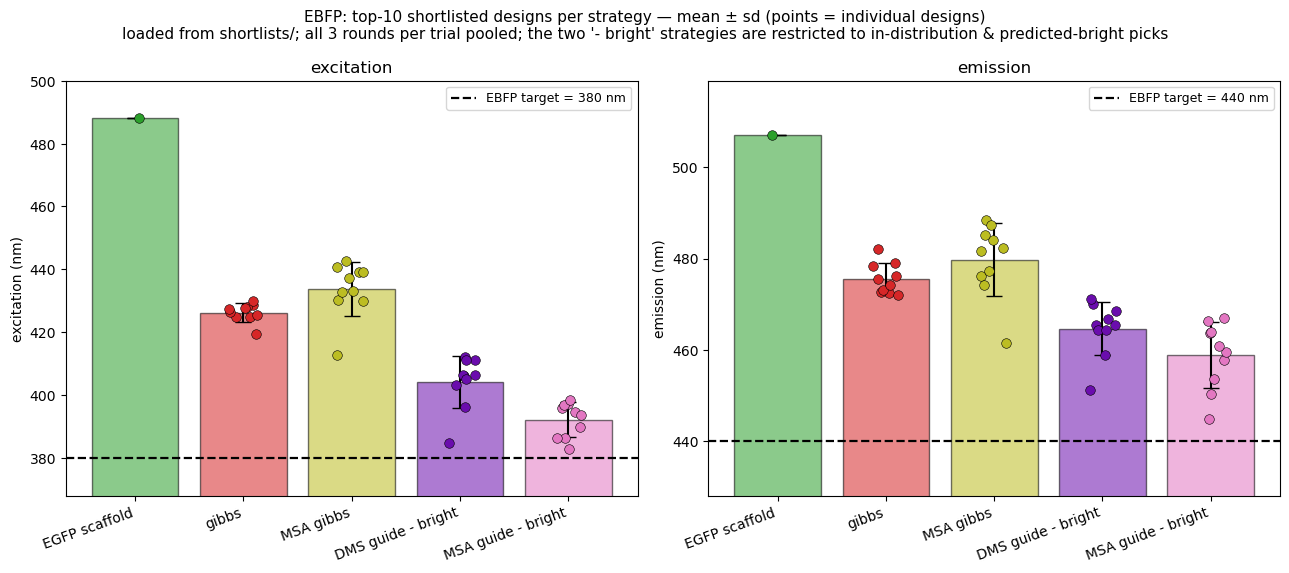

In [7]:
# --- Consolidated top-10 bar view, shared by EBFP and mOrange. Instead of re-selecting designs here,
#     this LOADS the finalized per-strategy shortlists in shortlists/*.xlsx (built by
#     make_shortlist_case.py) and plots exactly those picks, so the figure and the wet-lab hand-off
#     never drift. Each shortlist already carries the EGFP + target references (true ex/em) and the
#     top-10 diverse designs, with per-design is_id / is_bright flags. Every shortlist pools all 3
#     iteration rounds of every trial; the two "- bright" strategies (DMS guide, MSA guide) are then
#     restricted to in-distribution & predicted-bright designs before the top-10 is taken, while the
#     other three are unfiltered. Bars L->R: EGFP scaffold (green) + one bar per strategy present for
#     that target. Reuses DESIGNS, FIGDIR, REPO, pm, dev, torch from above.
CAMP = DESIGNS.parent.parent
SL = CAMP / "shortlists"
SHORTLISTS = {   # target -> [(alias, shortlist file, colour), ...]  (only the files we generated)
    "mOrange": [
        ("gibbs",                     "shortlist_mOrange_gibbs.xlsx",                      "#d62728"),
        ("MSA gibbs",                 "shortlist_mOrange_MSA-gibbs.xlsx",                 "#bcbd22"),
        ("spectra guide",             "shortlist_mOrange_spectra-guide.xlsx",             "0.45"),
        ("constrained spectra guide", "shortlist_mOrange_constrained-spectra-guide.xlsx", "#17becf"),
        ("DMS guide - bright",        "shortlist_mOrange_DMS-guide.xlsx",                 "#6a0dad"),
        ("MSA guide - bright",        "shortlist_mOrange_MSA-guide.xlsx",                 "#e377c2"),
    ],
    "EBFP": [
        ("gibbs",                     "shortlist_EBFP_gibbs.xlsx",                        "#d62728"),
        ("MSA gibbs",                 "shortlist_EBFP_MSA-gibbs.xlsx",                    "#bcbd22"),
        ("DMS guide - bright",        "shortlist_EBFP_DMS-guide.xlsx",                    "#6a0dad"),
        ("MSA guide - bright",        "shortlist_EBFP_MSA-guide.xlsx",                    "#e377c2"),
    ],
}
# Bars are ordered UNGUIDED FIRST, then guided, so each target reads left-to-right as "what the
# proposal alone gives you" -> "what adding the surrogate gives you". The two unguided bars share a
# proposal with a guided bar to their right (gibbs with the spectra guides, MSA gibbs with the MSA
# guide), which is what makes the steering effect readable off the figure.

# ---- brightness oracle (cnn-max-d2, val AUROC 0.98): kept here because the "strategy comparison"
#      cell below re-scores gibbs/spectra designs (no pred_bright column) with this SAME checkpoint. ----
BRIGHT_CKPT = REPO / "fpdesign" / "models" / "brightness_cnn-max-d2_40k.pt"
_BNET = {}
def _bnet():
    if "n" not in _BNET:
        _bb, _bm = pm.load_model(str(BRIGHT_CKPT), dev, out=1)
        _BNET["n"] = pm.wrap(_bb, _bm.get("mean", 0.0) or 0.0, _bm.get("std", 1.0) or 1.0, dev)
    return _BNET["n"]

@torch.no_grad()
def _score_bright(full_seqs, bs=32):
    net, out = _bnet(), []
    for i in range(0, len(full_seqs), bs):
        H, m = pm.resid_embed(list(full_seqs[i:i + bs]), dev)
        out.append(net(H, m).float().cpu().numpy().ravel())
    return np.concatenate(out) if out else np.array([])

def _load_shortlist(fname):
    d = pd.read_excel(SL / fname)
    refs = d[d["role"] == "reference"].set_index("name")
    des = d[d["role"] == "design"].copy()
    return refs, des

def plot_groups(target):
    specs = SHORTLISTS[target]
    refs, _ = _load_shortlist(specs[0][1])                       # all shortlists share EGFP + target refs
    sex, sem = float(refs.loc["EGFP", "true_ex_nm"]), float(refs.loc["EGFP", "true_em_nm"])
    tex, tem = float(refs.loc[target, "true_ex_nm"]), float(refs.loc[target, "true_em_nm"])
    labels = ["EGFP scaffold"] + [a for a, _, _ in specs]
    colors = ["#2ca02c"] + [c for _, _, c in specs]             # green leftmost bar = EGFP scaffold
    ex_data, em_data = [np.array([sex])], [np.array([sem])]
    print(f"=== {target}: loaded shortlists/ | scaffold ({sex:.0f}, {sem:.0f}) | target ({tex:.0f}, {tem:.0f}) ===")
    for alias, fname, _c in specs:
        _, des = _load_shortlist(fname)
        ex = des["pred_ex_nm"].to_numpy(float); em = des["pred_em_nm"].to_numpy(float)
        ex_data.append(ex); em_data.append(em)
        err = 0.5 * (np.abs(ex - tex) + np.abs(em - tem))
        n_id = int((des["is_id"] == "yes").sum()); n_br = int((des["is_bright"] == "yes").sum())
        print(f"  {alias:26} n={len(des)} | ex {ex.mean():.1f}\u00b1{ex.std(ddof=1):.1f} | "
              f"em {em.mean():.1f}\u00b1{em.std(ddof=1):.1f} | best err {err.min():.1f} nm | "
              f"ID {n_id}/{len(des)} | bright {n_br}/{len(des)}")
    x = np.arange(len(labels)); jit = np.random.default_rng(0)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))
    for ax, data, tgt, peak in [(axes[0], ex_data, tex, "excitation"),
                                (axes[1], em_data, tem, "emission")]:
        means = np.array([d.mean() if len(d) else np.nan for d in data])
        sds = np.array([d.std(ddof=1) if len(d) > 1 else 0.0 for d in data])
        ax.bar(x, means, yerr=sds, capsize=6, color=colors, alpha=0.55, edgecolor="k", zorder=2)
        for xi, d, c in zip(x, data, colors):
            ax.scatter(xi + (jit.random(len(d)) - 0.5) * 0.28, d, color=c, edgecolor="k",
                       linewidth=0.4, s=48, zorder=3)
        ax.axhline(tgt, ls="--", color="k", lw=1.6, zorder=4, label=f"{target} target = {tgt:.0f} nm")
        allv = np.concatenate(data + [np.array([tgt])])
        ax.set_ylim(allv.min() - 12, allv.max() + 12)
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_ylabel(f"{peak} (nm)"); ax.set_title(peak); ax.legend(fontsize=9, loc="best")
    fig.suptitle(f"{target}: top-10 shortlisted designs per strategy \u2014 mean \u00b1 sd "
                 f"(points = individual designs)\nloaded from shortlists/; all 3 rounds per trial "
                 f"pooled; the two '- bright' strategies are restricted to in-distribution & "
                 f"predicted-bright picks", fontsize=11)
    plt.tight_layout()
    fig.savefig(FIGDIR / f"campaign_top10_bars_{target}.png", dpi=130, bbox_inches="tight")
    print("saved", FIGDIR / f"campaign_top10_bars_{target}.png")
    plt.show()

plot_groups("EBFP")

## Top-10 shortlisted designs per strategy vs target — mOrange

Same shortlist-driven view for **mOrange** (target ex/em 548/562 nm, a ~100 nm red-shift at ~30%
identity). Loads all five **`shortlists/shortlist_mOrange_*.xlsx`** files — **gibbs**, **spectra
guide**, **constrained spectra guide**, **DMS guide - bright**, and **MSA guide - bright** — and
plots exactly those top-10 picks, with the EGFP scaffold bar and the mOrange target line as above.
The two **- bright** strategies pool all 3 rounds per trial and are restricted to designs that are
in-distribution **and** predicted bright before the top-10 is taken; the other three are unfiltered,
so their bars answer a different question and should not be read as a like-for-like ranking.
**MSA guide** additionally pools all **125 λ-sweep cells** (851 ID & bright of 2,635 unique designs),
a deeper pool than the 288 designs the single-setting strategies draw from.

=== mOrange: loaded shortlists/ | scaffold (488, 507) | target (548, 562) ===
  gibbs                      n=10 | ex 495.4±3.1 | em 515.2±2.0 | best err 44.7 nm | ID 0/10 | bright 0/10
  MSA gibbs                  n=10 | ex 508.8±3.1 | em 525.1±8.1 | best err 29.2 nm | ID 0/10 | bright 0/10
  spectra guide              n=10 | ex 544.5±0.9 | em 562.4±0.6 | best err 1.7 nm | ID 0/10 | bright 0/10
  constrained spectra guide  n=10 | ex 542.6±3.7 | em 562.4±3.5 | best err 0.8 nm | ID 1/10 | bright 0/10
  DMS guide - bright         n=10 | ex 511.0±4.4 | em 536.5±3.6 | best err 24.2 nm | ID 10/10 | bright 10/10
  MSA guide - bright         n=10 | ex 541.2±1.2 | em 563.7±1.7 | best err 3.4 nm | ID 10/10 | bright 10/10


saved figures/campaign_top10_bars_mOrange.png


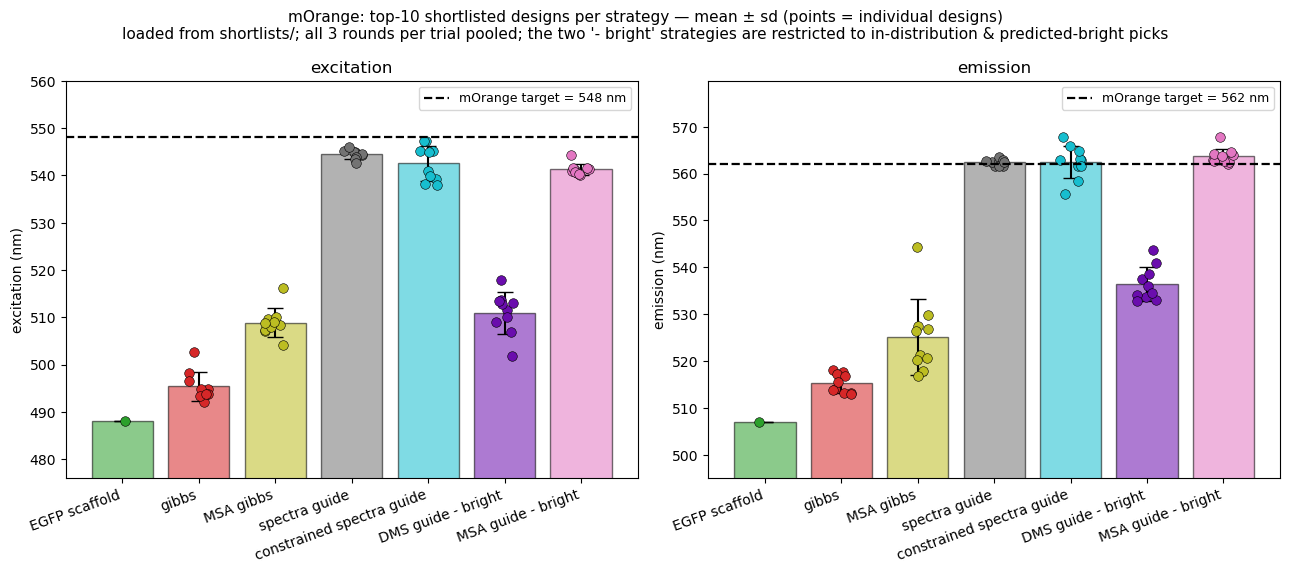

In [8]:
plot_groups("mOrange")

## Mutation load of the shortlisted top-10, per strategy

The two bar charts above show *where each shortlist landed spectrally*; this one shows **how far it
had to travel to get there**. Same shortlist files, same strategy order and colours, but counting
substitutions from the EGFP scaffold instead of predicted peaks. Every mutation is inside the
25-position Tier-B window by construction, so that count is a hard ceiling (dashed line).

This is the axis on which the strategies are most obviously *not* equivalent, and it is the one that
matters most for whether a design folds: mutation load is the strongest single correlate of the
brightness classifier's verdict (−0.73 to −0.85 across the MSA λ-sweep). Read it together with the
`is_id` / `is_bright` counts printed under the ex/em charts — a strategy that hits the target peaks
with 18 mutations is making a very different bet from one that gets close with 6.

The ordering is the same on both targets and tracks the objective exactly: the two unguided
strategies sit near the 25-position ceiling (gibbs 22–23, MSA gibbs 18–19, since nothing pulls
them back toward the scaffold), the spectra guide is barely better at 21.1, adding the edit penalty
brings it to 15.5, and the two brightness-steered strategies land at 9–11. **MSA guide is the most
parsimonious on both targets** (9.8 EBFP, 8.7 mOrange) while also being the most accurate of the
in-distribution strategies — it is not buying its peak accuracy with mutations.

**The green line on the EBFP panel is the uncomfortable one.** Real EBFP is **2 substitutions** from
EGFP; our best shortlist needs ~10 and still misses the peaks by 5.6 nm. Nothing in the search is
broken — the winning cell runs `λ_edit = 0`, so parsimony was never rewarded, and the surrogate
has no reason to prefer the two-mutation solution unless it predicts the shift. But it is a concrete
reminder that a 10-mutation design is a far riskier wet-lab bet than the known precedent for the
same target, and it suggests an edit-penalty-weighted rerun is worth doing for EBFP specifically.
(No such line on the mOrange panel: at 236 aa vs EGFP's 239 it is a DsRed derivative, not a
substitution series, so a Hamming count is not defined.)

=== EBFP: substitutions from EGFP among the shortlisted top-10 (25 editable positions) ===
  gibbs                       22.6 ±  1.0 | range 21-24
  MSA gibbs                   18.1 ±  2.5 | range 13-22
  DMS guide - bright          10.7 ±  1.1 | range 9-12
  MSA guide - bright           9.8 ±  2.0 | range 7-12
=== mOrange: substitutions from EGFP among the shortlisted top-10 (25 editable positions) ===
  gibbs                       22.2 ±  1.8 | range 18-24
  MSA gibbs                   18.7 ±  1.7 | range 16-21
  spectra guide               21.1 ±  1.4 | range 19-23
  constrained spectra guide   15.5 ±  2.7 | range 12-20
  DMS guide - bright          10.3 ±  1.8 | range 8-13
  MSA guide - bright           8.7 ±  1.9 | range 6-12


saved figures/campaign_top10_mutations.png


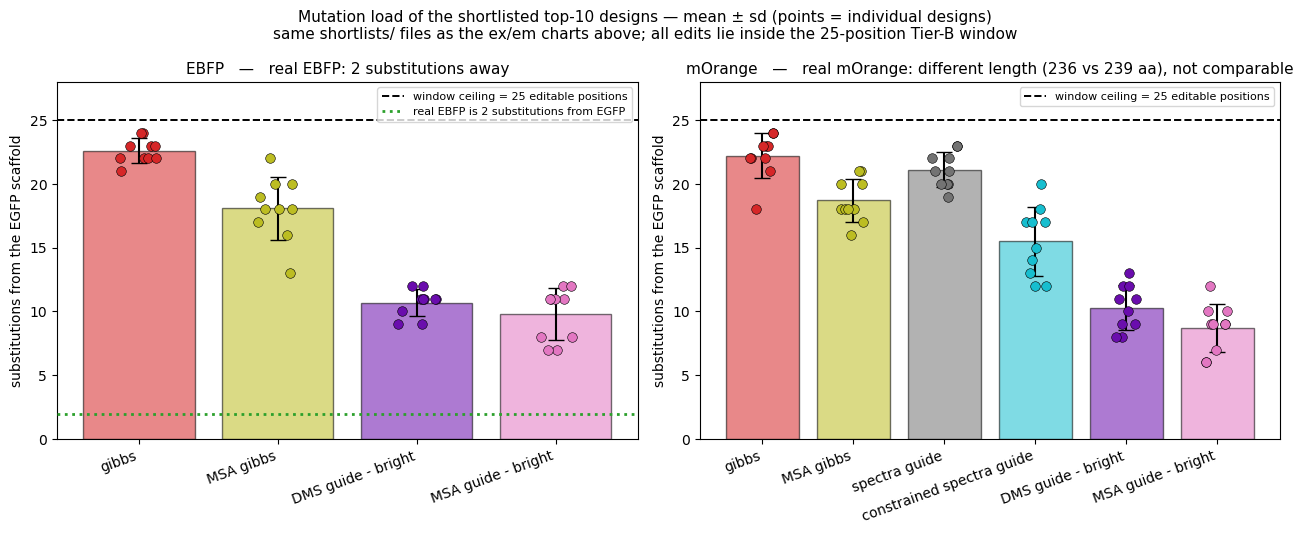

In [9]:
# ---- Mutation load of the shortlisted top-10, per strategy -----------------------------------
# Companion to the two ex/em bar charts above: same shortlist xlsx files, same strategy order and
# colours, but counting substitutions from the EGFP scaffold rather than predicted peaks. Every
# design is a pure substitution series inside the 25-position Tier-B window, so that count is a hard
# ceiling. Reuses SHORTLISTS, _load_shortlist, CAMP, FIGDIR from the cells above.
import json

WINJ = json.load(open(CAMP / "design_windows_egfp_tierB.json"))["windows"]["EGFP"]
N_EDIT = len(WINJ["editable_0based"])

def _hamming(a, b):
    return sum(x != y for x, y in zip(a, b))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, target in zip(axes, ["EBFP", "mOrange"]):
    specs = SHORTLISTS[target]
    refs, _ = _load_shortlist(specs[0][1])              # all shortlists share the EGFP + target refs
    egfp_aa, tgt_aa = refs.loc["EGFP", "aa_sequence"], refs.loc[target, "aa_sequence"]
    labels = [a for a, _, _ in specs]; colors = [c for _, _, c in specs]
    data = []
    print(f"=== {target}: substitutions from EGFP among the shortlisted top-10 "
          f"({N_EDIT} editable positions) ===")
    for alias, fname, _c in specs:
        _, des = _load_shortlist(fname)
        n = np.array([_hamming(s, egfp_aa) for s in des["aa_sequence"]])
        data.append(n)
        print(f"  {alias:26} {n.mean():5.1f} \u00b1 {n.std(ddof=1):4.1f} | range {n.min()}-{n.max()}")
    x = np.arange(len(labels)); jit = np.random.default_rng(0)
    ax.bar(x, [d.mean() for d in data], yerr=[d.std(ddof=1) for d in data], capsize=6,
           color=colors, alpha=0.55, edgecolor="k", zorder=2)
    for xi, d, c in zip(x, data, colors):
        ax.scatter(xi + (jit.random(len(d)) - 0.5) * 0.28, d, color=c, edgecolor="k",
                   linewidth=0.4, s=48, zorder=3)
    ax.axhline(N_EDIT, ls="--", color="k", lw=1.4, zorder=4,
               label=f"window ceiling = {N_EDIT} editable positions")
    # the real target protein's own distance from EGFP, when the two are comparable at all: EBFP is
    # an avGFP point mutant (same length), mOrange is a DsRed derivative at ~30% identity, where a
    # substitution count is not a meaningful reference and is reported in the title instead.
    if len(tgt_aa) == len(egfp_aa):
        n_tgt = _hamming(tgt_aa, egfp_aa)
        ax.axhline(n_tgt, ls=":", color="#2ca02c", lw=2.0, zorder=4,
                   label=f"real {target} is {n_tgt} substitutions from EGFP")
        sub = f"real {target}: {n_tgt} substitutions away"
    else:
        sub = f"real {target}: different length ({len(tgt_aa)} vs {len(egfp_aa)} aa), not comparable"
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("substitutions from the EGFP scaffold")
    ax.set_ylim(0, N_EDIT + 3)
    ax.set_title(f"{target}   \u2014   {sub}", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Mutation load of the shortlisted top-10 designs \u2014 mean \u00b1 sd "
             "(points = individual designs)\nsame shortlists/ files as the ex/em charts above; all "
             "edits lie inside the 25-position Tier-B window", fontsize=11)
plt.tight_layout()
fig.savefig(FIGDIR / "campaign_top10_mutations.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_top10_mutations.png")
plt.show()

## Design-strategy comparison — the new `guided +edit` vs the rest

A single bar chart placing every EGFP design strategy on the **two pairs they all share** — **EBFP**
(large blue shift, ~99% seq id) and **mOrange** (red shift, ~30% seq id). All use the same surrogate
metric `peak_err = ½(|Δex| + |Δem|)` and the same "**each trial's best round**" rule as the lollipops
above. Bars are the **mean over trials**; the black ▾ marks the single **best design**; the dashed red
line is the **scaffold's** starting error; the dotted line is 10 nm. Bar labels show the mean and the
per-strategy trial count `n` (strategies were run to different depths).

The strategies form a **2 × 2** over the only two things that really differ between them — where
candidates come from, and whether anything steers the choice:

| | unguided (gibbs) | surrogate-guided |
|---|---|---|
| **ESM-2 proposal** | `gibbs` | `guided-only`, `guided +edit`, `brightness +edit` |
| **family profile** | `MSA gibbs` | `MSA guide` |

Read down a column for the **proposal** effect in isolation and across a row for the **steering**
effect. Without the `MSA gibbs` cell you cannot tell whether the MSA guide's advantage comes from
the family profile or from the λ retuning that came with it.

Strategies:
- **gibbs** — pure ESM-2 masked-LM sampling (target-free; reconstructed per-target).
- **MSA gibbs** — *new*: the same sampling with the family profile as the conditional instead of
  ESM-2, and the surrogate removed from selection. It is the unguided control for **MSA guide**, and
  the two share a PSSM file so the comparison is exact ([`msa-gibbs/README.md`](msa-gibbs/README.md)).
- **guided-only** — surrogate peaks-only steering.
- **guided +edit λ=10** — peaks steering **plus** the `lam_edit=10` edit penalty toward the scaffold (no brightness term).
- **brightness λ=40 / λ=60 +edit** — peaks + classifier-brightness + edit penalty.
- **MSA guide λ=2/4/0** — *new*: the 763-sequence family alignment replaces ESM-2 as the proposal,
  and residues the family never uses at a window position are dropped from the alphabet outright.
  Its λ values sit on a **different (unit) scale** — every term is z-scored and `T=1`, so `2/4/0`
  here is *not* comparable as a number to the `20`–`60` above; only the resulting designs are
  comparable. Unlike the shortlist figures above, this bar uses the **single best sweep cell**, not
  the pooled sweep, so that every bar here is one tuned setting.

The `guided +edit λ=10` run isolates the edit penalty on top of plain guided steering: it stays
on-target (best 0.1 nm EBFP, 0.8 nm mOrange — matching or beating guided-only) while, by construction,
pulling designs toward fewer mutations from the bright EGFP parent.

The printed table also reports **% predicted-bright** — the fraction of each strategy's unique
round≥1 designs whose full sequence scores `cnn-max-d2` brightness logit > 0 (one oracle applied
uniformly). This shows how often a strategy *actually produces* bright candidates: without a
brightness term the rate is ≈0% (even `guided +edit`, i.e. fewer mutations alone), whereas the
brightness-steered runs are far higher (and rise with `lam_bright`).

saved figures/campaign_strategy_comparison.png

% predicted-bright (cnn-max-d2 logit > 0) over unique round≥1 designs:
pair                   EGFP → EBFP  EGFP → mOrange
strategy                                          
MSA gibbs                      0.0             0.0
MSA guide λ=2/4/0             53.0            75.0
brightness λ=60 +edit         80.0            34.0
gibbs                          0.0             0.0
guided +edit λ=10              0.0             0.0
guided-only                    0.0             0.0


,strategy,pair,mean_design,best_design,n_trials,scaffold_err,n_designs,pct_bright
0,gibbs,EGFP → EBFP,57.0,38.6,96,88.4,288,0.0
1,gibbs,EGFP → mOrange,63.8,44.7,96,56.6,288,0.0
2,MSA gibbs,EGFP → EBFP,70.0,27.1,96,88.3,288,0.0
3,MSA gibbs,EGFP → mOrange,53.6,29.2,96,56.7,288,0.0
4,guided-only,EGFP → EBFP,2.7,0.0,48,88.3,144,0.0
5,guided-only,EGFP → mOrange,15.7,1.7,96,56.7,288,0.0
6,guided +edit λ=10,EGFP → EBFP,1.9,0.1,48,88.3,144,0.0
7,guided +edit λ=10,EGFP → mOrange,20.5,0.8,96,56.7,288,0.0
8,brightness λ=60 +edit,EGFP → EBFP,30.5,6.4,96,88.3,284,79.9
9,brightness λ=60 +edit,EGFP → mOrange,39.1,17.4,96,56.7,287,34.1


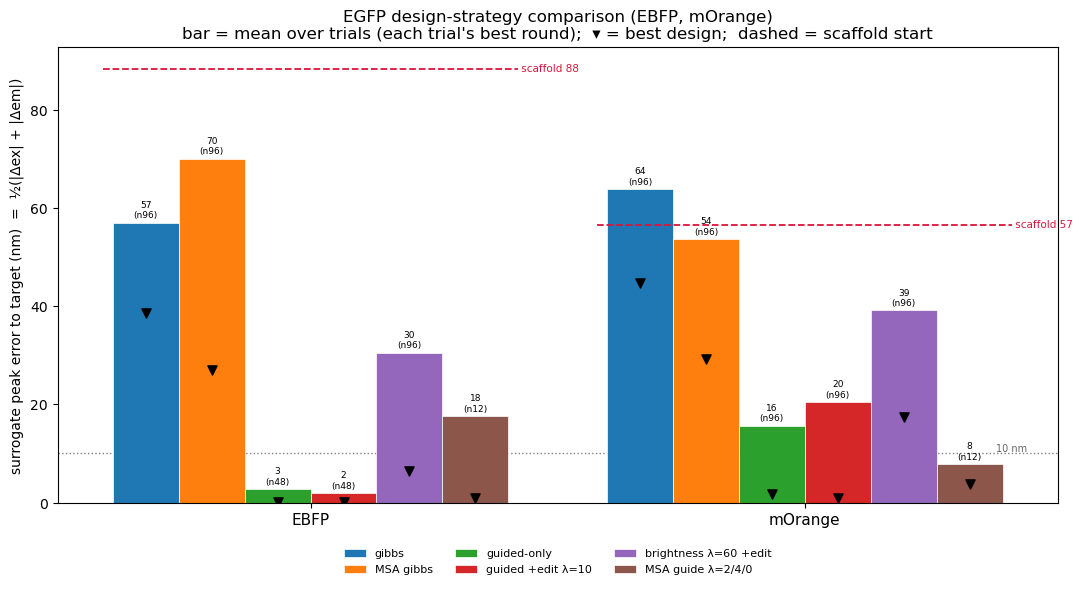

In [10]:
# ---- Strategy comparison bar chart (adds the new guided +edit constraint) --------------------
# Compares every EGFP design strategy on the two pairs they all share (EBFP, mOrange), using the same
# surrogate metric + "each trial's best round" rule as the per-pair lollipops above. Reuses df,
# dfg, DESIGNS, FIGDIR, load_designs, best_per_trial from the cells above.
CAMP = DESIGNS.parent.parent


def _load_if(dirpath):
    dirpath = Path(dirpath)
    return load_designs(dirpath) if glob.glob(str(dirpath / "design_*.csv")) else None


PAIRS_CMP = ["EGFP \u2192 EBFP", "EGFP \u2192 mOrange"]
STRAT_SETS = [
    ("gibbs",                      dfg),   # target-free, reconstructed per-target above
    # Same, but drawing from the family profile instead of ESM-2. Paired with "MSA guide" at the
    # bottom of this list it isolates the surrogate steering from the proposal: the two share a
    # proposal distribution and differ only in whether anything guides the choice.
    ("MSA gibbs",                  dfmg),
    ("guided-only",                df),    # surrogate peaks-only
    ("guided +edit \u03bb=10",     _load_if(CAMP / "guided-design-constraint" / "designs_lam-edit10")),
    ("brightness \u03bb=60 +edit", _load_if(CAMP / "brightness-guided" / "guided_design" / "designs_lam-bright60_lam-edit10")),
    # MSA-guided at its BEST SINGLE CELL, not the pooled sweep: every other bar here is one tuned
    # setting, and a mean over all 125 cells would average in the deliberately-bad corners of the
    # grid. (The shortlist/OOD figures above do pool the whole sweep -- different question.) Its
    # lambdas are on a DIFFERENT (unit) scale -- every term z-scored at T=1 -- so 2/4/0 is not
    # comparable to the 20-60 above as a number; only the resulting designs are comparable.
    ("MSA guide \u03bb=2/4/0",     _load_if(MSA_BEST)),
]
STRAT_SETS = [(n, d) for n, d in STRAT_SETS if d is not None]

recs = []
for name, d in STRAT_SETS:
    bt = best_per_trial(d)
    for p in PAIRS_CMP:
        b = bt.loc[bt["pair"] == p, "peak_err"]
        if b.empty:
            continue
        sc = d.loc[(d["pair"] == p) & (d["round"] == 0), "peak_err"].iloc[0]
        # % predicted-bright: score every unique design's FULL sequence with the same cnn-max-d2
        # brightness classifier (logit > 0 = bright), reusing _score_bright from the top-5 cell. This
        # applies ONE brightness oracle uniformly, so gibbs/guided (no pred_bright column) are scored
        # the same way as the brightness-guided runs.
        pool = d[(d["pair"] == p) & (d["round"] >= 1)].drop_duplicates("designed_seq")
        blog = _score_bright(pool["designed_seq"].tolist())
        pct_bright = 100.0 * float(np.mean(blog > 0)) if len(blog) else float("nan")
        recs.append(dict(strategy=name, pair=p, mean_design=b.mean(), best_design=b.min(),
                         n_trials=int(b.size), scaffold_err=sc,
                         n_designs=int(len(pool)), pct_bright=pct_bright))
cmp_df = pd.DataFrame(recs)

strat_order = [n for n, _ in STRAT_SETS]
cmap = plt.get_cmap("tab10")
colors = {n: cmap(i) for i, n in enumerate(strat_order)}

x = np.arange(len(PAIRS_CMP))
w = 0.8 / len(strat_order)
fig, ax = plt.subplots(figsize=(11, 6))
for i, name in enumerate(strat_order):
    sub = cmp_df[cmp_df["strategy"] == name].set_index("pair").reindex(PAIRS_CMP)
    xi = x - 0.4 + w * (i + 0.5)
    ax.bar(xi, sub["mean_design"], width=w, color=colors[name], edgecolor="white",
           linewidth=0.5, zorder=2, label=name)
    ax.scatter(xi, sub["best_design"], marker="v", s=44, color="black", zorder=4)
    for xv, mv, nt in zip(xi, sub["mean_design"], sub["n_trials"]):
        if np.isfinite(mv):
            ax.text(xv, mv + 0.6, f"{mv:.0f}\n(n{nt})", ha="center", va="bottom", fontsize=6.5)

for xc, p in zip(x, PAIRS_CMP):
    sc = cmp_df.loc[cmp_df["pair"] == p, "scaffold_err"].iloc[0]
    ax.hlines(sc, xc - 0.42, xc + 0.42, color="crimson", ls="--", lw=1.3, zorder=3)
    ax.text(xc + 0.42, sc, f" scaffold {sc:.0f}", va="center", fontsize=7.5, color="crimson")
ax.axhline(10, ls=":", color="0.5", lw=1, zorder=1)
ax.text(x[-1] + 0.45, 10, "10 nm", va="bottom", ha="right", fontsize=7, color="0.4")

ax.set_xticks(x)
ax.set_xticklabels([p.split("\u2192")[1].strip() for p in PAIRS_CMP], fontsize=11)
ax.set_ylabel("surrogate peak error to target (nm)  =  \u00bd(|\u0394ex| + |\u0394em|)")
ax.set_title("EGFP design-strategy comparison (EBFP, mOrange)\n"
             "bar = mean over trials (each trial's best round);  \u25be = best design;  dashed = scaffold start")
ax.legend(fontsize=8, ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.08))
fig.tight_layout()
fig.savefig(FIGDIR / "campaign_strategy_comparison.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_strategy_comparison.png")
print("\n% predicted-bright (cnn-max-d2 logit > 0) over unique round\u22651 designs:")
print(cmp_df.pivot(index="strategy", columns="pair", values="pct_bright").round(0).to_string())
cmp_df.round(1)